find five rows with dde around : -2.3, -1, 0 , 1, 6

use the d12 value above as z axis

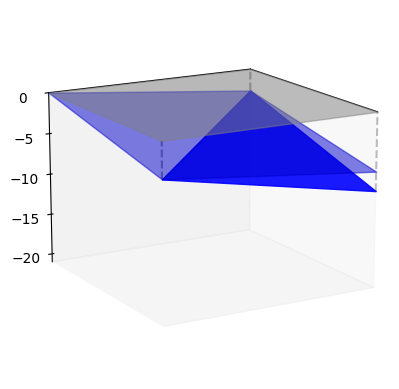

In [27]:
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

import matplotlib.pyplot as plt

xy_base = 21
de1 = -4.2870167233
de2 = -2.75427107699
de12 = -9.35661780029
# Define the vertices of the triangle
vertices = [[0, 0, 0], [0, xy_base, de1], [xy_base, 0, de2]]

# Create a 3D plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

################### Add the first triangle to the plot ###########################
triangle = Poly3DCollection([vertices], alpha=0.5,color='mediumblue')
ax.add_collection3d(triangle)

# Set the limits and labels
ax.set_xlim([0, xy_base])  # Reverse the x-axis
ax.set_ylim([xy_base, 0])
ax.set_zlim([-xy_base, 0])
ax.xaxis.set_ticks_position('upper')
ax.yaxis.set_ticks_position('upper')
ax.view_init(elev=15, azim=240)  # Rotate the graph counterclockwise by 30 degrees
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

###################################################################################



################## Define the vertices of the second triangle######################
vertices2 = [[xy_base, 0, de2], [0, xy_base, de1], [xy_base, xy_base, de12]]

# Add the second triangle to the plot
triangle2 = Poly3DCollection([vertices2], alpha=0.9, color='blue')
ax.add_collection3d(triangle2)
# Show the plot
####################################################################################


######## Plot straight lines from each vertex of the triangles to the xy surface#####
for vertex in vertices + vertices2:
    x, y, z = vertex
    ax.plot([x, x], [y, y], [z, 0], alpha=0.5,color='gray', linestyle='--')
####################################################################################


################## Define the vertices of the square ###############################
square_vertices = [[0, 0, 0], [0, xy_base, 0], [xy_base, xy_base, 0], [xy_base, 0, 0]]

# Add the square to the plot
square = Poly3DCollection([square_vertices], alpha=0.5, color='gray', edgecolor='gray')
ax.add_collection3d(square)
#####################################################################################


##################add dde = 0 triangle##################################################
#add a plot a triangle with verticies (0,xybase,de1) (xybase, 0, de2)(xybase,xybase, de1+de2)
# Define the vertices of the new triangle
vertices3 = [[0, xy_base, de1], [xy_base, 0, de2], [xy_base, xy_base, de1 + de2]]

# Add the new triangle to the plot
triangle3 = Poly3DCollection([vertices3], alpha=0.5, color='mediumblue')
ax.add_collection3d(triangle3)



#######################################################################################
ax.grid(False)
ax.set_xticks([])
ax.set_yticks([])
# ax.set_zticks([])
ax.set_xlabel('')
ax.set_ylabel('')

plt.show()

In [28]:
def plot_3d_triangles(xy_base, de1, de2, de12):
    import matplotlib.pyplot as plt
# Adjust the figure size to make the canvas larger for annotations
    # Define the vertices of the first triangle
    plane_color = 'darkblue'
    vertices = [[0, 0, 0], [0, xy_base, de1], [xy_base, 0, de2]]

    # Create a 3D plot
    fig = plt.figure()
    fig.set_size_inches(10, 10)
    ax = fig.add_subplot(111, projection='3d')

    # Add the first triangle to the plot
    triangle = Poly3DCollection([vertices], alpha=0.5, color=plane_color)
    ax.add_collection3d(triangle)

    # Set the limits and labels
    ax.set_xlim([0, xy_base])
    ax.set_ylim([xy_base, 0])
    ax.set_zlim([-xy_base, 0])
    ax.xaxis.set_ticks_position('upper')
    ax.yaxis.set_ticks_position('upper')
    ax.view_init(elev=5, azim=240)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('ΔE', rotation=90)

    # Define the vertices of the second triangle
    vertices2 = [[xy_base, 0, de2], [0, xy_base, de1], [xy_base, xy_base, de12]]

    # Add the second triangle to the plot
    color = 'darkred' if dde < 0 else 'darkgreen'
    triangle2 = Poly3DCollection([vertices2], alpha=0.5, color=color)
    ax.add_collection3d(triangle2)

    # Plot straight lines from each vertex of the triangles to the xy surface
    for vertex in vertices + vertices2:
        x, y, z = vertex
        ax.plot([x, x], [y, y], [z, 0], alpha=0.5, color='gray', linestyle='--')

    # Define the vertices of the square
    square_vertices = [[0, 0, 0], [0, xy_base, 0], [xy_base, xy_base, 0], [xy_base, 0, 0]]

    # Add the square to the plot
    square = Poly3DCollection([square_vertices], alpha=0.5, color='gray', edgecolor='gray')
    ax.add_collection3d(square)

    # Add a triangle with vertices (0, xy_base, de1), (xy_base, 0, de2), (xy_base, xy_base, de1 + de2)
    vertices3 = [[0, xy_base, de1], [xy_base, 0, de2], [xy_base, xy_base, de1 + de2]]
    triangle3 = Poly3DCollection([vertices3], alpha=0.5, color=plane_color)
    ax.add_collection3d(triangle3)

    # add dde lable:
    # Draw a solid line between the x-coordinates of the second and third triangle
    line_color = 'darkgreen' if dde > 0 else 'darkred'
    ax.plot([vertices2[2][0], vertices3[2][0]],  # x-coordinates
            [vertices2[2][1], vertices3[2][1]],  # y-coordinates
            [vertices2[2][2], vertices3[2][2]],  # z-coordinates
            color=line_color, linewidth=2)

    # # Label the ΔΔE value
    # label_position = [(vertices2[2][0] + vertices3[2][0]) / 2,
    #                   (vertices2[2][1] + vertices3[2][1]) / 2,
    #                   min(vertices2[2][2], vertices3[2][2]) - 2]  # Adjusted Z position to be slightly below the bottom of the line
    # ax.text(label_position[0], label_position[1], label_position[2],
    #         f"ΔΔE: {dde:.2f}", color=line_color, fontsize=10, ha='center')
    
    ax.grid(False)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_zticks([])
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_zlabel('')

    plt.show()

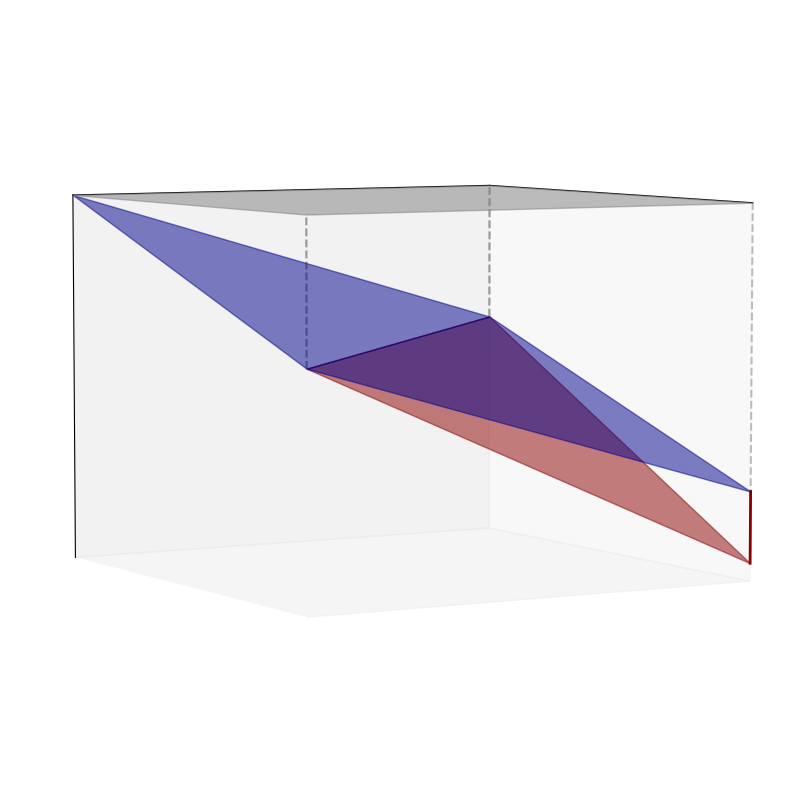

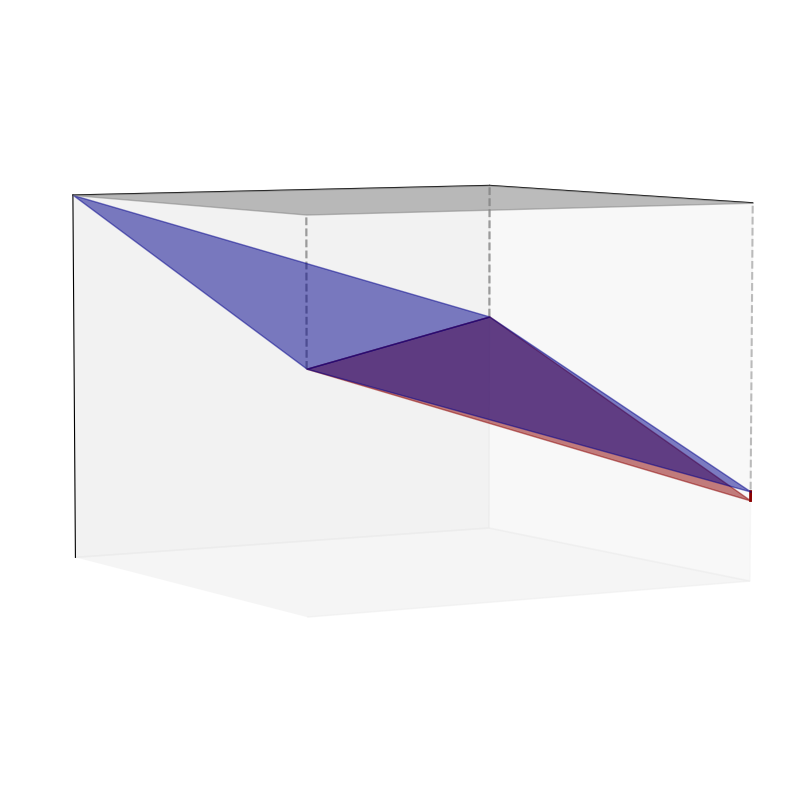

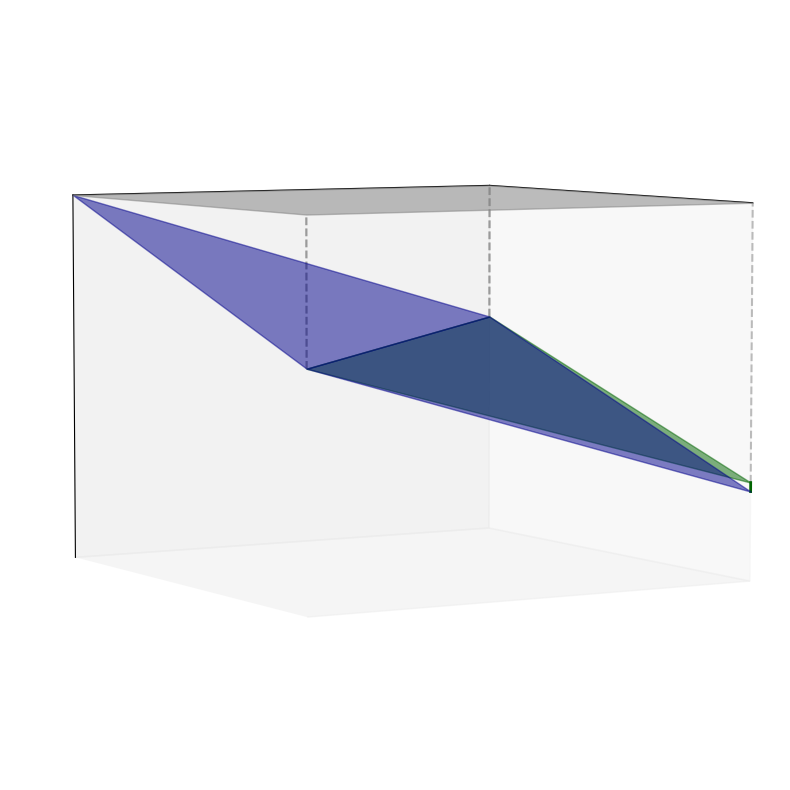

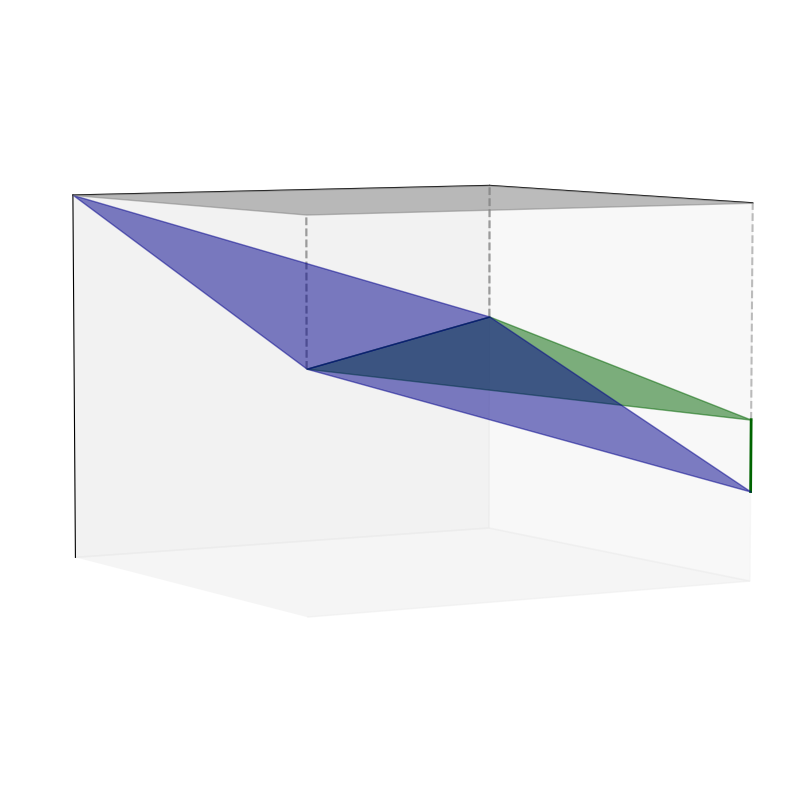

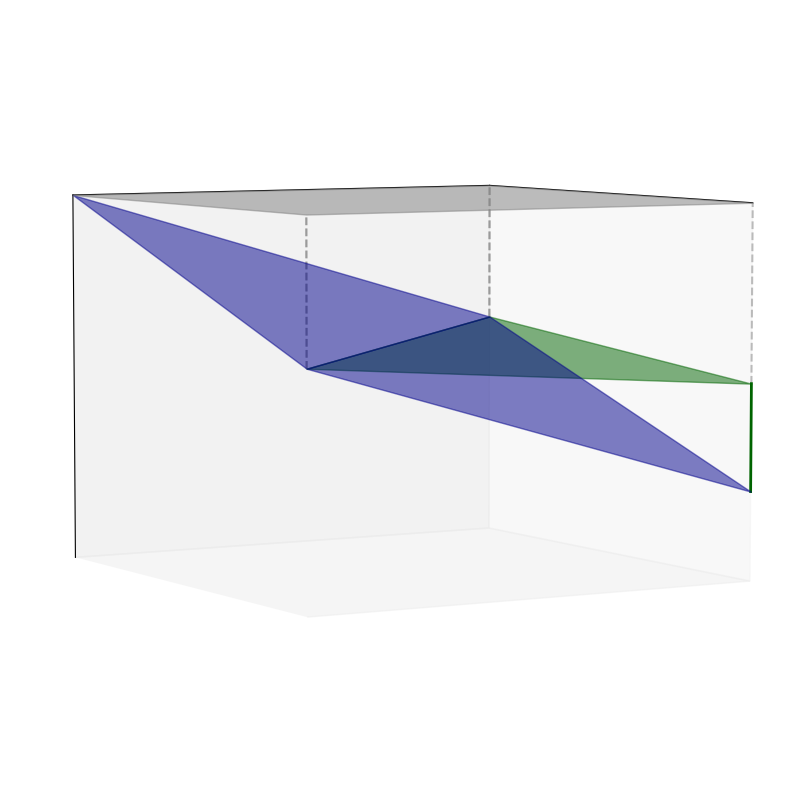

In [29]:

# rows_to_plot = [
#     ('D39A-B256A', -2.31533, -4.2870167233, -2.75427107699, -9.35661780029),
#     ('B6A-D119B', -1.03091, -9.06889346242, -2.99199003726, -13.091793499680001),
#     ('A1B-B2A', 0.012168, -8.38054968975, -12.211337151, -20.579718840749997),
#     ('B2A-C124A', 1.07828, -12.211337151, -0.429158587009, -11.562215738009002),
#     ('B6A-C7B', 6.06472, -9.06889346242, -5.61920403084, -8.62337749326)
# ]

# Define semantic data with fixed de1 and de2 values
de1_fixed = -8
de2_fixed = -8

# Calculate de12 for each row based on dde, de1, and de2
rows_to_plot = [
    ('Mutation1', -4, de1_fixed, de2_fixed, de1_fixed + de2_fixed - 4),
    ('Mutation2', -0.5, de1_fixed, de2_fixed, de1_fixed + de2_fixed - 0.5),
    ('Mutation3', 0.5, de1_fixed, de2_fixed, de1_fixed + de2_fixed + 0.5),
    ('Mutation4', 4, de1_fixed, de2_fixed, de1_fixed + de2_fixed + 4),
    ('Mutation5', 6, de1_fixed, de2_fixed, de1_fixed + de2_fixed + 6)
]

# Plot each row as a triangle
for row in rows_to_plot:
    _, dde, de1, de2, de12 = row
    plot_3d_triangles(xy_base, de1, de2, de12)


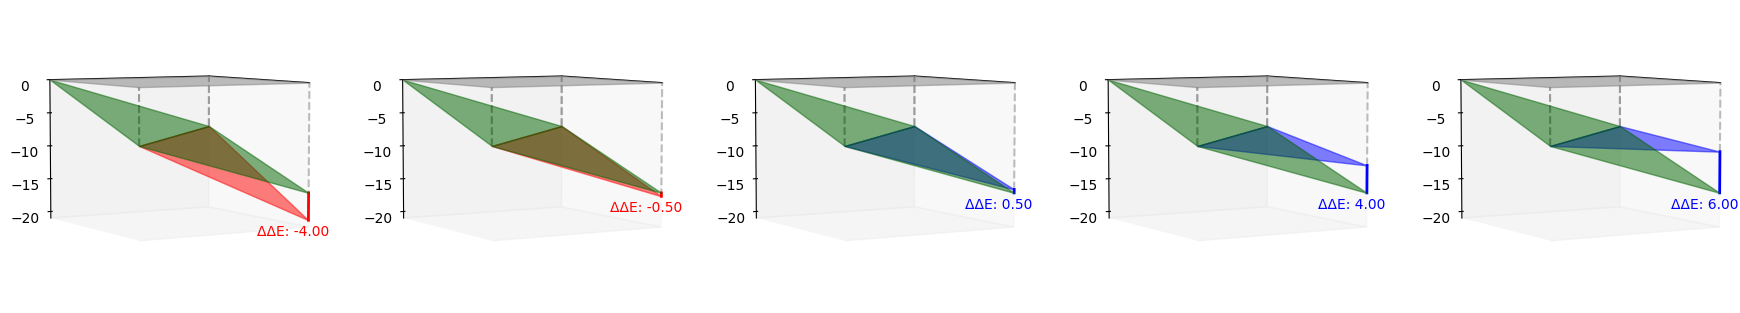

In [30]:
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

import matplotlib.pyplot as plt

# Create a figure with 1 row and 5 columns of subplots
fig, axes = plt.subplots(1, 5, subplot_kw={'projection': '3d'}, figsize=(22, 4))

# Iterate over the rows to plot each graph
for ax, row in zip(axes, rows_to_plot):
    _, dde, de1, de2, de12 = row
    plane_color = 'darkgreen'
    vertices = [[0, 0, 0], [0, xy_base, de1], [xy_base, 0, de2]]

    # Add the first triangle to the plot
    triangle = Poly3DCollection([vertices], alpha=0.5, color=plane_color)
    ax.add_collection3d(triangle)

    # Define the vertices of the second triangle
    vertices2 = [[xy_base, 0, de2], [0, xy_base, de1], [xy_base, xy_base, de12]]

    # Add the second triangle to the plot
    color = 'red' if dde < 0 else 'blue'
    triangle2 = Poly3DCollection([vertices2], alpha=0.5, color=color)
    ax.add_collection3d(triangle2)

    # Plot straight lines from each vertex of the triangles to the xy surface
    for vertex in vertices + vertices2:
        x, y, z = vertex
        ax.plot([x, x], [y, y], [z, 0], alpha=0.5, color='gray', linestyle='--')

    # Define the vertices of the square
    square_vertices = [[0, 0, 0], [0, xy_base, 0], [xy_base, xy_base, 0], [xy_base, 0, 0]]

    # Add the square to the plot
    square = Poly3DCollection([square_vertices], alpha=0.5, color='gray', edgecolor='gray')
    ax.add_collection3d(square)

    # Add a triangle with vertices (0, xy_base, de1), (xy_base, 0, de2), (xy_base, xy_base, de1 + de2)
    vertices3 = [[0, xy_base, de1], [xy_base, 0, de2], [xy_base, xy_base, de1 + de2]]
    triangle3 = Poly3DCollection([vertices3], alpha=0.5, color=plane_color)
    ax.add_collection3d(triangle3)

    # Draw a solid line between the x-coordinates of the second and third triangle
    line_color = 'blue' if dde > 0 else 'red'
    ax.plot([vertices2[2][0], vertices3[2][0]],  # x-coordinates
            [vertices2[2][1], vertices3[2][1]],  # y-coordinates
            [vertices2[2][2], vertices3[2][2]],  # z-coordinates
            color=line_color, linewidth=2)

    # Label the ΔΔE value
    label_position = [(vertices2[2][0] + vertices3[2][0]) / 2 -2,
                      (vertices2[2][1] + vertices3[2][1]) / 2,
                      min(vertices2[2][2], vertices3[2][2]) - 2]  # Adjusted Z position to be slightly below the bottom of the line
    ax.text(label_position[0], label_position[1], label_position[2],
            f"ΔΔE: {dde:.2f}", color=line_color, fontsize=10, ha='center')

    # Set the limits and labels
    ax.set_xlim([0, xy_base])
    ax.set_ylim([xy_base, 0])
    ax.set_zlim([-xy_base, 0])
    ax.xaxis.set_ticks_position('upper')
    ax.yaxis.set_ticks_position('upper')
    ax.view_init(elev=5, azim=240)
    ax.grid(False)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel('')
    ax.set_ylabel('')

# Adjust layout and show the plot
# Adjust the spacing to prevent the last picture from being cut off
# plt.subplots_adjust(left=0.05, right=0.95, top=0.9, bottom=0.1, wspace=0.3)
plt.show()